In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')

from src.features import add_lag_features,add_calendar_features,add_rolling_features

df = pd.read_csv(r'C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\processed_data\enriched_data.csv')
print(df.shape)
print(df.head())

(26304, 6)
             timestamp         load  hour  day_of_week  month  year
0  2023-01-01 00:00:00  5317.916667     0            6      1  2023
1  2023-01-01 01:00:00  5271.333333     1            6      1  2023
2  2023-01-01 02:00:00  5142.833333     2            6      1  2023
3  2023-01-01 03:00:00  5110.250000     3            6      1  2023
4  2023-01-01 04:00:00  5126.833333     4            6      1  2023


In [2]:
import numpy as np

In [3]:
df = add_calendar_features(df)
df = add_rolling_features(df)
df = add_lag_features(df)

In [4]:
df = df.dropna()

In [5]:
df.head()

,timestamp,load,hour,day_of_week,month,year,hour_sin,hour_cos,dow_sin,dow_cos,...,rolling_std_24,rolling_mean_48,rolling_std_48,rolling_mean_168,rolling_std_168,lag_1,lag_2,lag_24,lag_48,lag_168
168,2023-01-08 00:00:00,5709.50,0,6,1,2023,0.000000,1.000000,-0.781831,0.62349,...,772.695969,6194.968750,735.450059,6297.699405,684.279363,6252.50,6828.50,5706.25,5930.5,5317.916667
169,2023-01-08 01:00:00,5501.25,1,6,1,2023,0.258819,0.965926,-0.781831,0.62349,...,772.560459,6190.364583,737.828870,6300.030258,681.583568,5709.50,6252.50,5507.50,5561.5,5271.333333
170,2023-01-08 02:00:00,5439.25,2,6,1,2023,0.500000,0.866025,-0.781831,0.62349,...,772.892562,6189.109375,738.971833,6301.398810,679.733994,5501.25,5709.50,5390.75,5583.5,5142.833333
171,2023-01-08 03:00:00,5409.75,3,6,1,2023,0.707107,0.707107,-0.781831,0.62349,...,770.064576,6186.104167,741.775088,6303.163194,677.088254,5439.25,5501.25,5361.00,5444.5,5110.250000
172,2023-01-08 04:00:00,5376.75,4,6,1,2023,0.866025,0.500000,-0.781831,0.62349,...,767.124060,6185.380208,742.530852,6304.945933,674.317182,5409.75,5439.25,5358.25,5414.5,5126.833333


In [6]:
df.shape

(26136, 23)

In [7]:
import seaborn as sns

<Axes: >

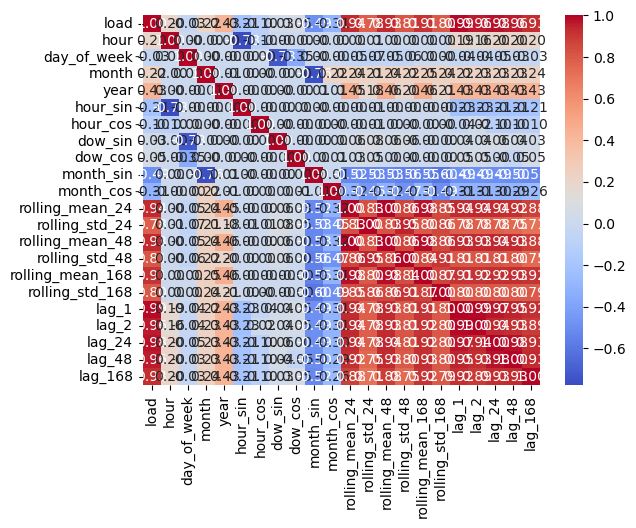

In [8]:
sns.heatmap(df.drop('timestamp', axis=1).corr(), annot=True, fmt=".2f", cmap='coolwarm')

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

In [10]:
df.to_csv('feature_engineered_data.csv')